### Let's explore the options for multiclass classification in Yellowbrick

Many of the tools are pretty much the same conventional metrics we've used already.

It seems this is the trade-off if one chooses to go with multiclass classification.

You get better outputs (probability for each class), which makes the model "smarter" output-wise, but at the same time, we can't use most of the clever tools related to binary classification due to how multiclass predictions work.

This might also explain why binary classification datasets seem more common in the field (Kaggle etc.)

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from yellowbrick.classifier import (
    ConfusionMatrix, ClassificationReport, ClassPredictionError,
    PrecisionRecallCurve, ROCAUC
)


### Yellowbrick visualizations

In [2]:
import pandas as pd
from sklearn.model_selection import train_test_split

# load data
df = pd.read_csv("../lifestyle_sustainability_data.csv")

# handle these better with your own dataset, here we are simply dropping these
df = df.drop(['ParticipantID'], axis=1)


In [3]:
# this just converts the value of column to 0 or 1
# factorize in pandas works too, but only one column at a time
from sklearn.preprocessing import LabelEncoder
variables = ["SustainableBrands"]
encoder = LabelEncoder()
df[variables] = df[variables].apply(encoder.fit_transform)

In [4]:
 # this example is using the housing data from Moodle
varlist_three = ["CommunityInvolvement", "PhysicalActivities"]
varlist_four = ["LocalFoodFrequency", "ClothingFrequency", "UsingPlasticProducts"]

# Defining the map function
def binary_map_three(x):
    return x.map({'Low': 0, "Moderate": 1, "High": 2})

# Defining the map function
def binary_map_four(x):
    return x.map({'Rarely': 0, "Sometimes": 1, "Often": 2, "Always": 3})

# Applying the function to the housing list
df[varlist_three] = df[varlist_three].apply(binary_map_three)
df[varlist_four] = df[varlist_four].apply(binary_map_four)

In [5]:
 # this makes multiple columns with the variable (Separate for yes/no)
from sklearn.preprocessing import OneHotEncoder
variables = ["Location", "DietType", "TransportationMode", "EnergySource", "HomeType", "Gender", "DisposalMethods"]

# use encoder
encoder = OneHotEncoder(sparse_output=False).set_output(transform="pandas")
one_hot_encoded = encoder.fit_transform(df[variables]).astype(int)
df = pd.concat([df,one_hot_encoded],axis=1).drop(columns=variables)

In [6]:
# CommunityInvolvement                 118
# UsingPlasticProducts                  95
# PhysicalActivities                   108

df['CommunityInvolvement'] = df['CommunityInvolvement'].fillna(0.0)
df['UsingPlasticProducts'] = df['UsingPlasticProducts'].fillna(3.0)
df['PhysicalActivities'] = df['PhysicalActivities'].fillna(0.0)

In [7]:
# we can always remove one of the onehotencoded variables, 
# remove: 'DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling'
removables = ['DietType_Mostly Plant-Based',  'TransportationMode_Walk',  'EnergySource_Renewable', 'HomeType_Other', 'Gender_Prefer not to say', 'DisposalMethods_Recycling']
df = df.drop(removables, axis=1)

In [8]:
# XGBoost requires ordinals to be from 0 onwards
# let's fix that
df['Rating'] = df['Rating'] - 1.0
df['Rating'] = df['Rating'].astype(int)

In [9]:

# Define features and target
X = df.drop("Rating", axis=1)
y = df['Rating']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [10]:
# Assuming you already have X_train, X_test, y_train, y_test from your DataFrame splits
import xgboost as xgb
# model = RandomForestClassifier(random_state=42)
model = xgb.XGBClassifier(tree_method='gpu_hist', objective="multi:softproba", num_class=5)
model.fit(X_train, y_train)


,objective,'multi:softprob'
,use_label_encoder,None
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [11]:
class_names = sorted(y_train.unique())
print("Classes:", class_names)


Classes: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


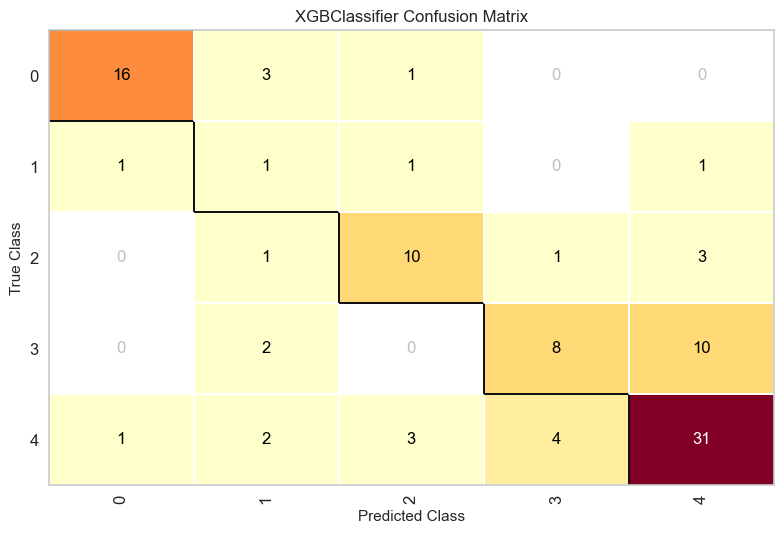

<Axes: title={'center': 'XGBClassifier Confusion Matrix'}, xlabel='Predicted Class', ylabel='True Class'>

In [12]:
cm_viz = ConfusionMatrix(model, classes=class_names, percent=False)
cm_viz.fit(X_train, y_train)
cm_viz.score(X_test, y_test)
cm_viz.show()


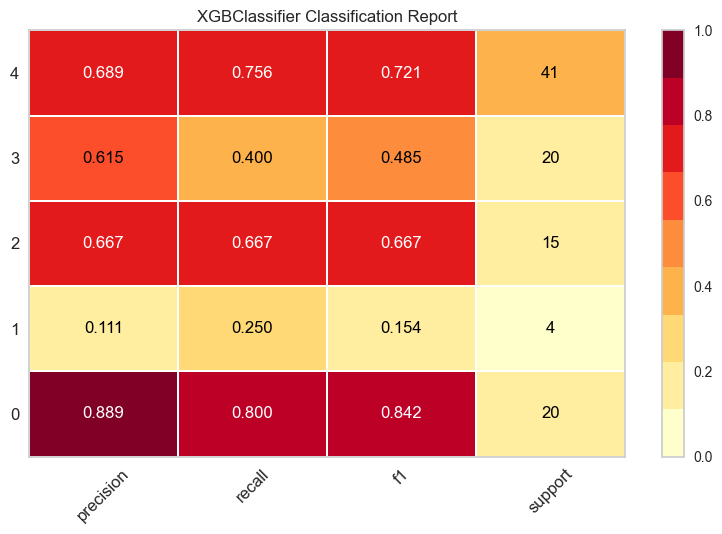

Accuracy: 0.6600


In [13]:
cr_viz = ClassificationReport(model, classes=class_names, support=True)
cr_viz.fit(X_train, y_train)
cr_viz.score(X_test, y_test)
cr_viz.show()

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, model.predict(X_test))
print(f"Accuracy: {accuracy:.4f}")


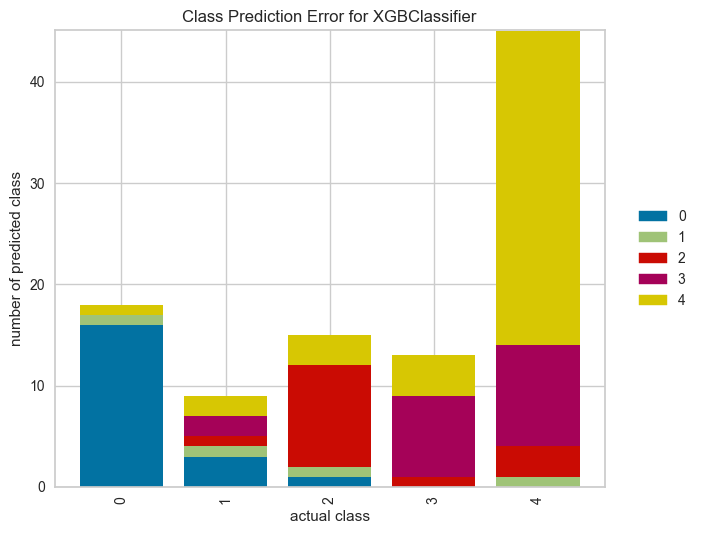

<Axes: title={'center': 'Class Prediction Error for XGBClassifier'}, xlabel='actual class', ylabel='number of predicted class'>

In [14]:
cpe_viz = ClassPredictionError(model, classes=class_names)
cpe_viz.fit(X_train, y_train)
cpe_viz.score(X_test, y_test)
cpe_viz.show()

# this is another version of confusion matrix, to see how things are misclassified
# actually quite useful!


c:\Users\tuomas.valtanen\advda2025lecturenotes\AdvancedDataAnalytics2025\.venv\Lib\site-packages\yellowbrick\classifier\prcurve.py:254: YellowbrickWarning: micro=True is ignored;specify per_class=False to draw a PR curve after micro-averaging
  warnings.warn(


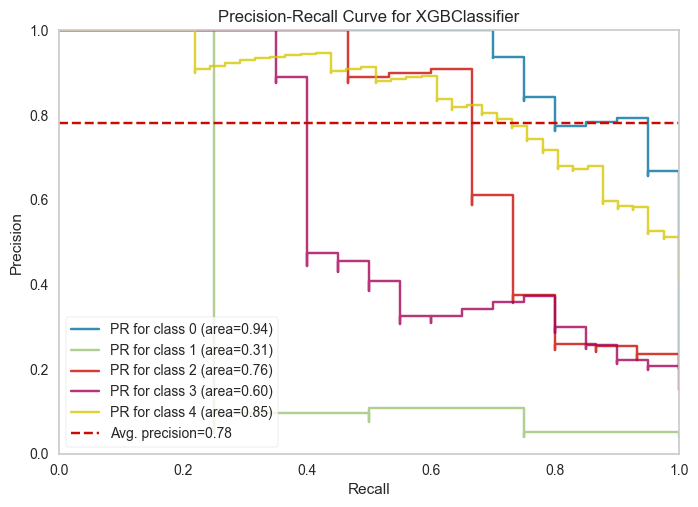

<Axes: title={'center': 'Precision-Recall Curve for XGBClassifier'}, xlabel='Recall', ylabel='Precision'>

In [15]:
prc_viz = PrecisionRecallCurve(model, per_class=True, classes=class_names)
prc_viz.fit(X_train, y_train)
prc_viz.score(X_test, y_test)
prc_viz.show()

# what to look for:

# a curve hugging the top-right curner is ideal => perfect classification (not in this case)
# sharp drop in curve or stays low => poor precision or recall at most thresholds

# in a nutshell => the curves should be as close to top right as possible
# if any of the curves is not => this class has problems in classification

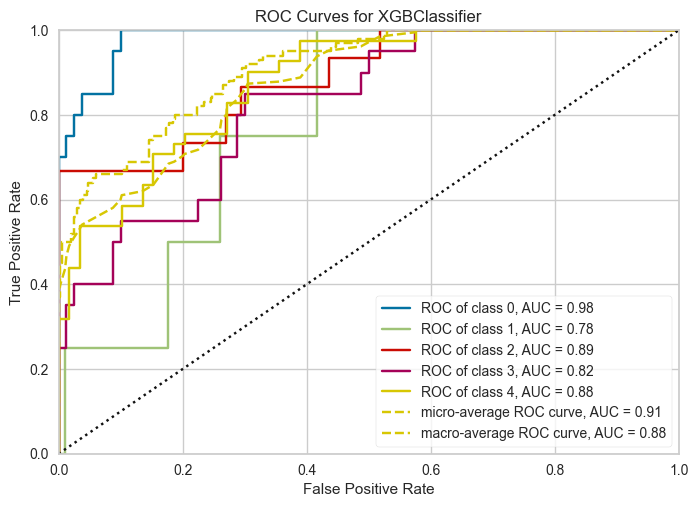

<Axes: title={'center': 'ROC Curves for XGBClassifier'}, xlabel='False Positive Rate', ylabel='True Positive Rate'>

In [16]:
roc_viz = ROCAUC(model, classes=class_names)
roc_viz.fit(X_train, y_train)
roc_viz.score(X_test, y_test)
roc_viz.show()

# micro average = global ROC AUC, overall performance
# macro average = per class ROC AUC, all classes treated equally regardless of the amount of data they had

In [17]:
# technically the result of PR and ROCAUC => you can see the same thing in confusion matrix too
# when inspecting which classes make mistakes with each other